In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

# Load data
df = pd.read_csv("../data/fda_resolved.csv")

# Split groups
group_a = df[df['classification'] == 'Class I']['resolution_days']
group_b = df[df['classification'] == 'Class II']['resolution_days']

print(f"Data Loaded — {df.shape[0]:,} records")

Data Loaded — 14,746 records


In [5]:
# Frequentist results
t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)
diff = group_a.mean() - group_b.mean()
se = np.sqrt(group_a.var()/len(group_a) + group_b.var()/len(group_b))
ci_lower_freq = diff - 1.96 * se
ci_upper_freq = diff + 1.96 * se

# Bayesian results
n_samples = 100000
posterior_a = np.random.normal(group_a.mean(), 
               group_a.std()/np.sqrt(len(group_a)), n_samples)
posterior_b = np.random.normal(group_b.mean(), 
               group_b.std()/np.sqrt(len(group_b)), n_samples)
diff_samples = posterior_a - posterior_b
prob_a_slower = (posterior_a > posterior_b).mean()
ci_lower_bayes = np.percentile(diff_samples, 2.5)
ci_upper_bayes = np.percentile(diff_samples, 97.5)

# Comparison table
comparison = pd.DataFrame({
    'Metric': [
        'Class I Mean',
        'Class II Mean',
        'Difference',
        'Statistical Evidence',
        'Interval Lower (95%)',
        'Interval Upper (95%)',
        'Conclusion'
    ],
    'Frequentist': [
        f'{group_a.mean():.0f} days',
        f'{group_b.mean():.0f} days',
        f'{diff:.0f} days',
        f'P-Value = {p_value:.10f}',
        f'{ci_lower_freq:.0f} days',
        f'{ci_upper_freq:.0f} days',
        'Significant'
    ],
    'Bayesian': [
        f'{group_a.mean():.0f} days',
        f'{group_b.mean():.0f} days',
        f'{diff_samples.mean():.0f} days',
        f'P(Class I slower) = {prob_a_slower*100:.2f}%',
        f'{ci_lower_bayes:.0f} days',
        f'{ci_upper_bayes:.0f} days',
        'Significant'
    ]
})

comparison.style.set_properties(**{
    'text-align': 'left',
    'font-size': '13px'
}).hide(axis='index')

Metric,Frequentist,Bayesian
Class I Mean,968 days,968 days
Class II Mean,651 days,651 days
Difference,316 days,316 days
Statistical Evidence,P-Value = 0.0000000000,P(Class I slower) = 100.00%
Interval Lower (95%),289 days,290 days
Interval Upper (95%),343 days,343 days
Conclusion,Significant,Significant


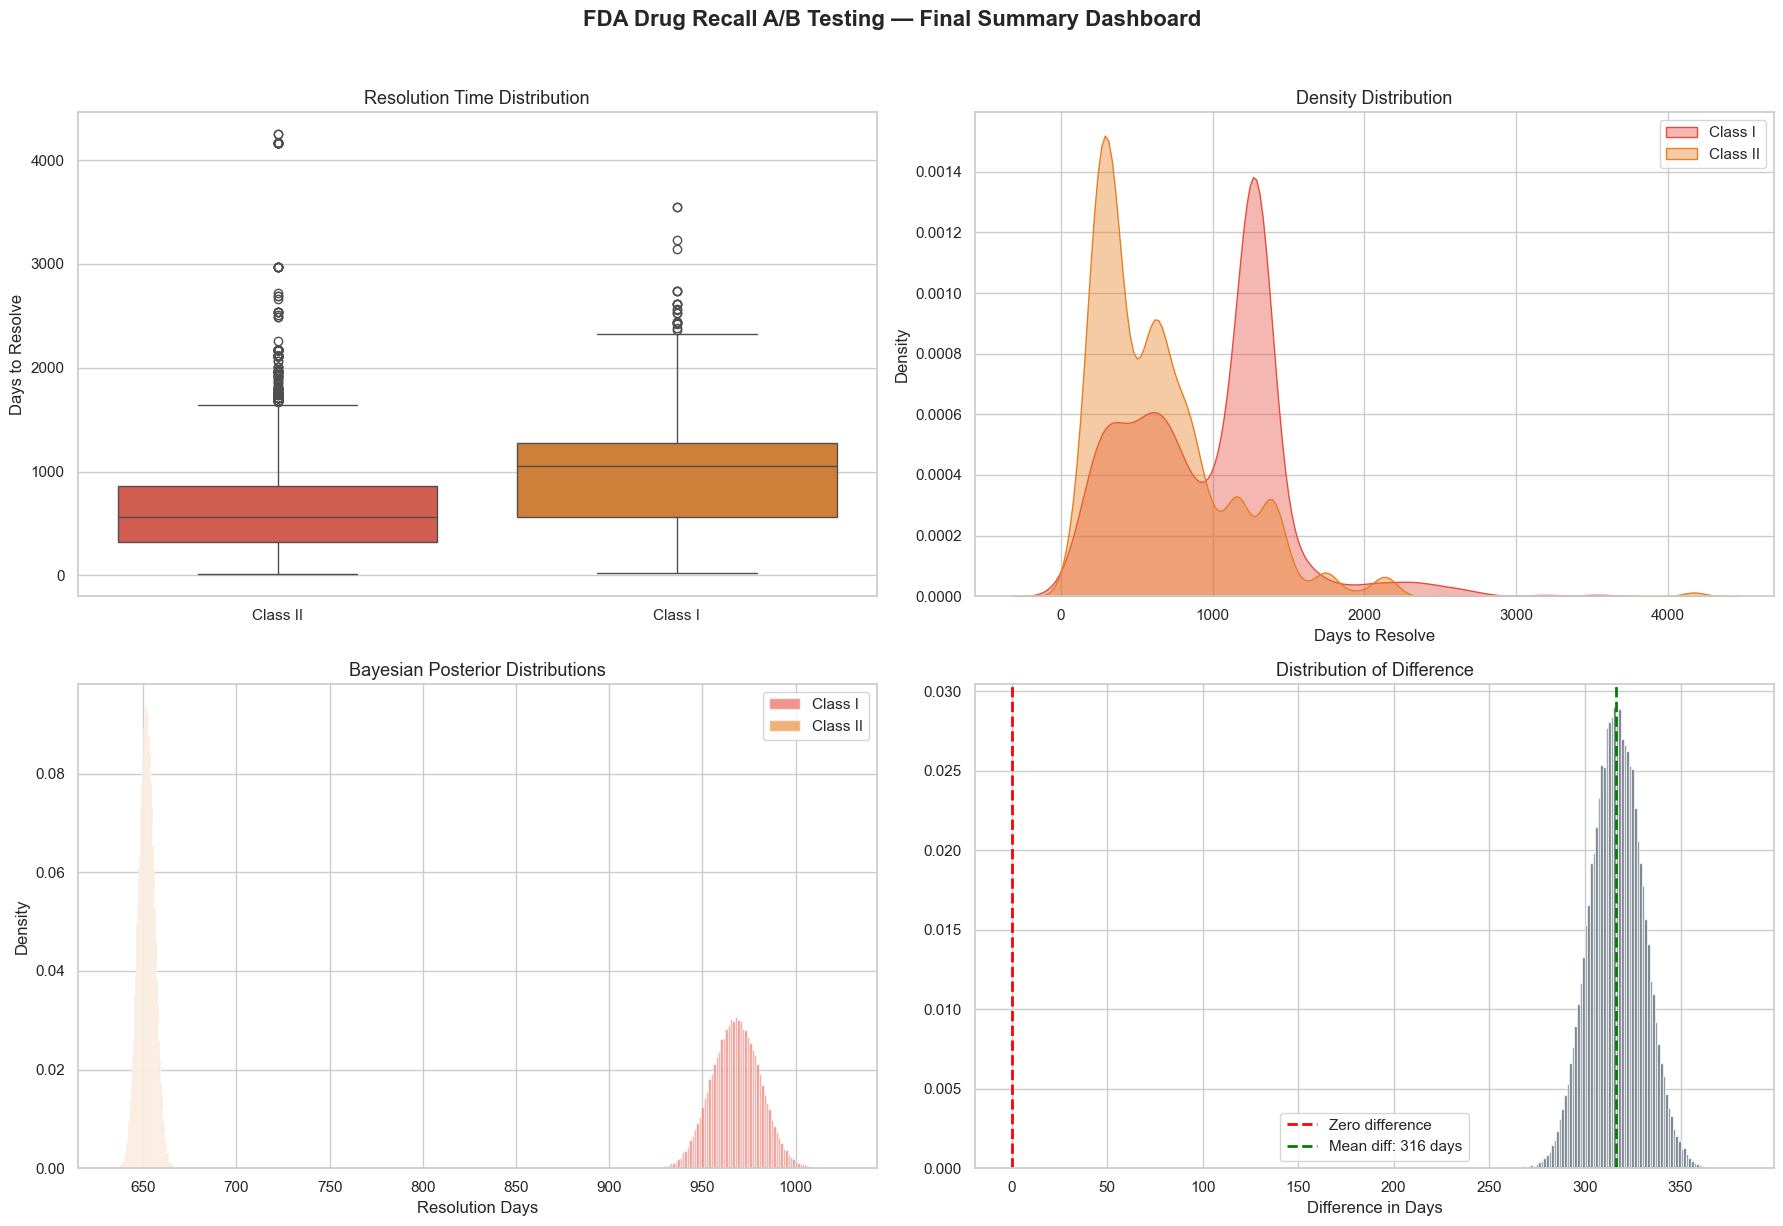

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('FDA Drug Recall A/B Testing — Final Summary Dashboard', 
             fontsize=16, fontweight='bold', y=1.02)

# Chart 1 — Boxplot comparison
sns.boxplot(
    data=df[df['classification'].isin(['Class I', 'Class II'])],
    x='classification', y='resolution_days',
    palette=['#e74c3c', '#e67e22'], ax=axes[0,0]
)
axes[0,0].set_title('Resolution Time Distribution', fontsize=13)
axes[0,0].set_ylabel('Days to Resolve')
axes[0,0].set_xlabel('')

# Chart 2 — KDE distribution
sns.kdeplot(group_a, ax=axes[0,1], label='Class I',
            color='#e74c3c', fill=True, alpha=0.4)
sns.kdeplot(group_b, ax=axes[0,1], label='Class II',
            color='#e67e22', fill=True, alpha=0.4)
axes[0,1].set_title('Density Distribution', fontsize=13)
axes[0,1].set_xlabel('Days to Resolve')
axes[0,1].legend()

# Chart 3 — Posterior distributions
axes[1,0].hist(posterior_a, bins=100, alpha=0.6,
               color='#e74c3c', label='Class I', density=True)
axes[1,0].hist(posterior_b, bins=100, alpha=0.6,
               color='#e67e22', label='Class II', density=True)
axes[1,0].set_title('Bayesian Posterior Distributions', fontsize=13)
axes[1,0].set_xlabel('Resolution Days')
axes[1,0].set_ylabel('Density')
axes[1,0].legend()

# Chart 4 — Difference distribution
axes[1,1].hist(diff_samples, bins=100,
               color='#2c3e50', alpha=0.7, density=True)
axes[1,1].axvline(0, color='red', linestyle='--',
                  linewidth=2, label='Zero difference')
axes[1,1].axvline(diff_samples.mean(), color='green',
                  linestyle='--', linewidth=2,
                  label=f'Mean diff: {diff_samples.mean():.0f} days')
axes[1,1].set_title('Distribution of Difference', fontsize=13)
axes[1,1].set_xlabel('Difference in Days')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/07_final_dashboard.png', 
            dpi=150, bbox_inches='tight')
plt.show()

## 📋 Final Business Recommendation

### Key Finding
Class I drug recalls the most dangerous recalls that pose 
serious risk to human life, taken on average **316 days longer** 
to resolve than Class II recalls.

### Statistical Evidence
| Method | Result |
|---|---|
| Frequentist | P-Value = 0.0000  |
| Bayesian | 100% probability 
|
| Confidence Interval | 289 — 343 days |

### Why Does This Happen?
- Class I recalls require more **FDA oversight and verification**
- More **legal and regulatory steps** are involved
- Companies face **higher scrutiny** for dangerous recalls
- Resolution requires **more thorough investigation**

### Recommendation To FDA & Pharma Companies
1. Allocate **more resources** to Class I recall resolution teams
2. Create a **fast track process** specifically for Class I cases
3. Set a target resolution time of **under 500 days** for Class I
4. Monitor companies with **recurring Class I recalls** closely

### Limitations
- Data only covers **resolved recalls** here ongoing cases excluded
- Some recalls may have **multiple classifications** over time
- **2026 data is incomplete** as year still in progress
- Observational study **causation cannot be assumed**

In [12]:
print("        FINAL PROJECT PRINT")
print(f"\nTotal Records Analyzed  : 14,746")
print(f"Class I Records         : 1,464")
print(f"Class II Records        : 11,778")
print(f"Mean Difference         : 316 days")
print(f"P-Value                 : 0.0000000000")
print(f"Bayesian Probability    : 100%")
print(f"Credible Interval       : 289 — 343 days")
print("\nNotebooks Completed:")
print("01_EDA.ipynb")
print("02_cleaning.ipynb")
print("03_frequentist.ipynb")
print("04_bayesian.ipynb")
print("05_summary.ipynb")

        FINAL PROJECT PRINT

Total Records Analyzed  : 14,746
Class I Records         : 1,464
Class II Records        : 11,778
Mean Difference         : 316 days
P-Value                 : 0.0000000000
Bayesian Probability    : 100%
Credible Interval       : 289 — 343 days

Notebooks Completed:
01_EDA.ipynb
02_cleaning.ipynb
03_frequentist.ipynb
04_bayesian.ipynb
05_summary.ipynb
